In [16]:
import ipywidgets as widgets
import matplotlib.pyplot as plt

import numpy as np
import pandas as pd

import wot

from pathlib import Path

In [8]:
DATA_PATH = Path('/home/jyj/PROJECT/2025/submission/data')

In [9]:
# Path to input files
FLE_COORDS_PATH =DATA_PATH / 'fle_coords.txt'
FULL_DS_PATH = DATA_PATH / 'ExprMatrix.h5ad'
VAR_DS_PATH = DATA_PATH / 'ExprMatrix.var.genes.h5ad'
CELL_DAYS_PATH = DATA_PATH / 'cell_days.txt'
GENE_SETS_PATH = DATA_PATH / 'gene_sets.gmx'
GENE_SET_SCORES_PATH = DATA_PATH / 'gene_set_scores.csv'
CELL_SETS_PATH = DATA_PATH / 'cell_sets.gmt'

coord_df = pd.read_csv(FLE_COORDS_PATH, index_col='id', sep='\t')
days_df = pd.read_csv(CELL_DAYS_PATH, index_col='id', sep='\t')


Text(0.5, 1.0, 'Day')

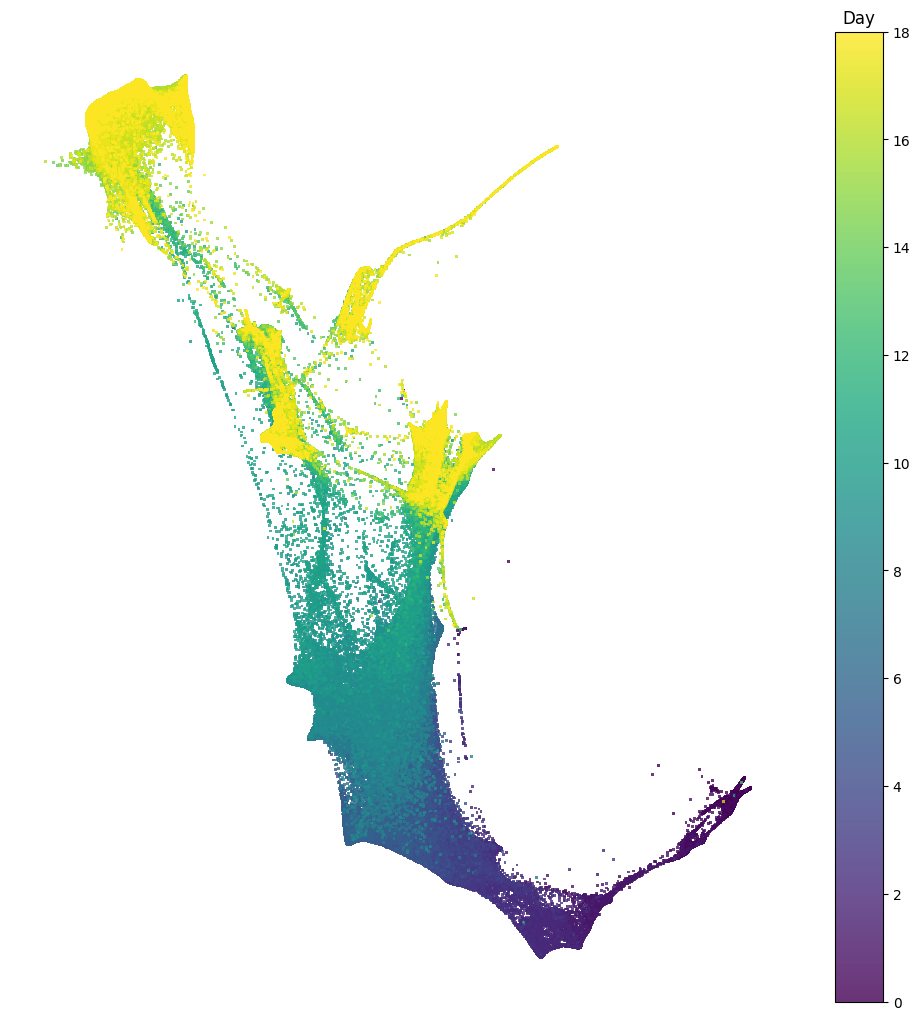

In [17]:
# Read expression matrix, cell days, and 2-d coordinates
adata = wot.io.read_dataset(FULL_DS_PATH, obs=[days_df,coord_df])
unique_days = adata.obs['day'].unique()
unique_days = unique_days[np.isnan(unique_days) == False]
# plot visualization coordinates
figure = plt.figure(figsize=(10, 10))
plt.axis('off')
plt.tight_layout()
plt.scatter(adata.obs['x'], adata.obs['y'],c=adata.obs['day'],
               s=4, marker=',', edgecolors='none', alpha=0.8)
cb = plt.colorbar()
cb.ax.set_title('Day')